<a href="https://colab.research.google.com/github/abenfaddoul/ML-Customer-Analytics/blob/main/CustomerSegmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***Advanced Mall Customer Segmentation Analysis***

# This notebook provides a comprehensive analysis of mall customer data using advanced statistical and machine learning techniques.

#  **Table of Contents**
# 1. Setup and Data Loading
# 2. Advanced Data Exploration
# 3. Statistical Analysis
# 4. Feature Engineering
# 5. Advanced Visualizations
# 6. Customer Segmentation
# 7. Segment Profiling



In [30]:
# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [10, 6]

# Load the dataset
data = pd.read_csv("Mall_Customers.csv")

#  1. Advanced Data Exploration

In [31]:
def perform_advanced_eda(df):
    """
    Perform advanced exploratory data analysis
    """
    # Basic statistics with additional metrics
    stats_df = pd.DataFrame({
        'Data Type': df.dtypes,
        'Missing Values': df.isnull().sum(),
        'Missing (%)': (df.isnull().sum() / len(df) * 100).round(2),
        'Unique Values': df.nunique(),
        'Skewness': df.select_dtypes(include=[np.number]).skew()
    })

    print("Advanced Data Statistics:")
    display(stats_df)
    # Check for outliers using IQR method
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    outliers = {}

    for col in numerical_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers[col] = len(df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)])

    print("\nNumber of outliers per column:")
    print(pd.Series(outliers))

In [32]:
# Perform advanced EDA
perform_advanced_eda(data)

Advanced Data Statistics:


,Data Type,Missing Values,Missing (%),Unique Values,Skewness
Age,int64,0,0.0,51,0.485569
Annual Income (k$),int64,0,0.0,64,0.321843
CustomerID,int64,0,0.0,200,0.000000
Gender,object,0,0.0,2,NaN
Spending Score (1-100),int64,0,0.0,84,-0.047220



Number of outliers per column:
CustomerID                0
Age                       0
Annual Income (k$)        2
Spending Score (1-100)    0
dtype: int64


#  **2. Statistical Analysis**

In [38]:
def perform_statistical_analysis(df):
    """
    Perform detailed statistical analysis
    """
    # Normality tests
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    normality_tests = {}

    for col in numerical_cols:
        stat, p_value = stats.normaltest(df[col])
        normality_tests[col] = {'statistic': stat, 'p_value': p_value}

    print("Normality Test Results:")
    display(pd.DataFrame(normality_tests).round(3))

    # Gender comparison using t-tests
    gender_tests = {}
    for col in numerical_cols:
        if col != 'CustomerID':
            male_data = df[df['Gender'] == 'Male'][col]
            female_data = df[df['Gender'] == 'Female'][col]
            stat, p_value = stats.ttest_ind(male_data, female_data)
            gender_tests[col] = {'t_statistic': stat, 'p_value': p_value}

    print("\nGender Comparison T-Tests:")
    display(pd.DataFrame(gender_tests).round(3))



In [39]:
# Perform statistical analysis
data = data.drop('CustomerID', axis=1)
perform_statistical_analysis(data)

Normality Test Results:


,Age,Annual Income (k$),Spending Score (1-100)
statistic,15.578,3.511,16.302
p_value,0.000,0.173,0.000



Gender Comparison T-Tests:


,Age,Annual Income (k$),Spending Score (1-100)
t_statistic,0.858,0.795,-0.819
p_value,0.392,0.428,0.414


# 3. Feature Engineering

In [34]:
# %% [markdown]
# ## 3. Feature Engineering

# %%
def engineer_features(df):
    """
    Create new features from existing data
    """
    df_new = df.copy()

    # Age groups
    df_new['Age_Group'] = pd.cut(df_new['Age'],
                                bins=[0, 20, 30, 40, 50, 100],
                                labels=['0-20', '21-30', '31-40', '41-50', '50+'])

    # Income categories
    df_new['Income_Category'] = pd.qcut(df_new['Annual Income (k$)'],
                                      q=5,
                                      labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

    # Spending categories
    df_new['Spending_Category'] = pd.qcut(df_new['Spending Score (1-100)'],
                                        q=5,
                                        labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

    # Spending to Income Ratio
    df_new['Spending_to_Income_Ratio'] = (df_new['Spending Score (1-100)'] /
                                         df_new['Annual Income (k$)']).round(2)

    return df_new

# Engineer new features
enhanced_data = engineer_features(data)

# 4. Advanced Visualizations

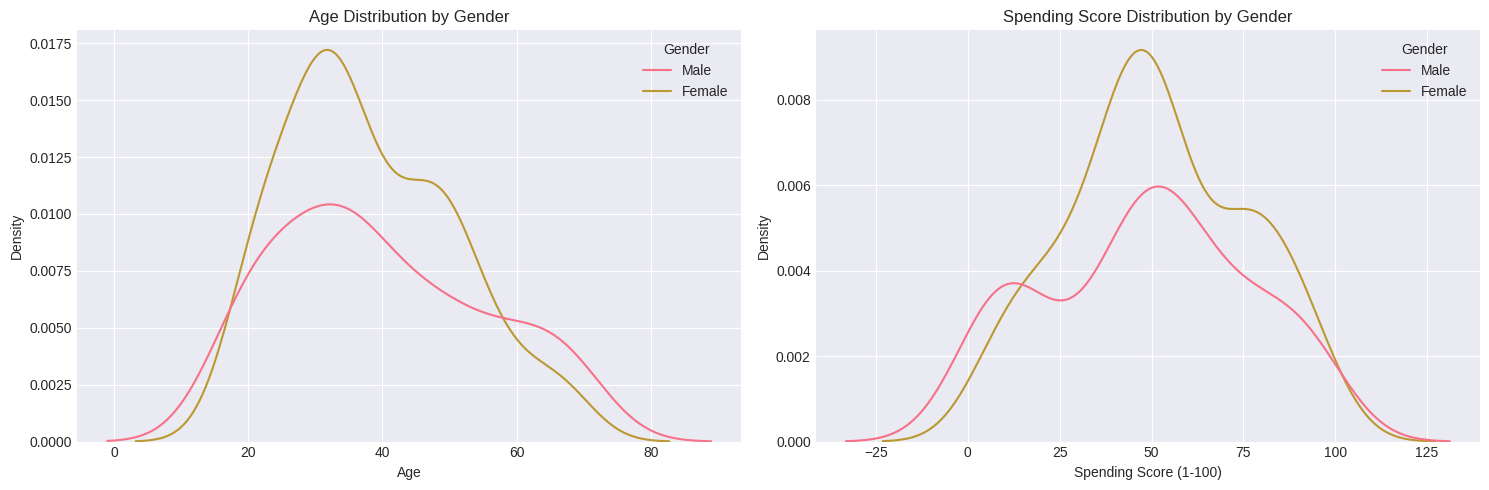

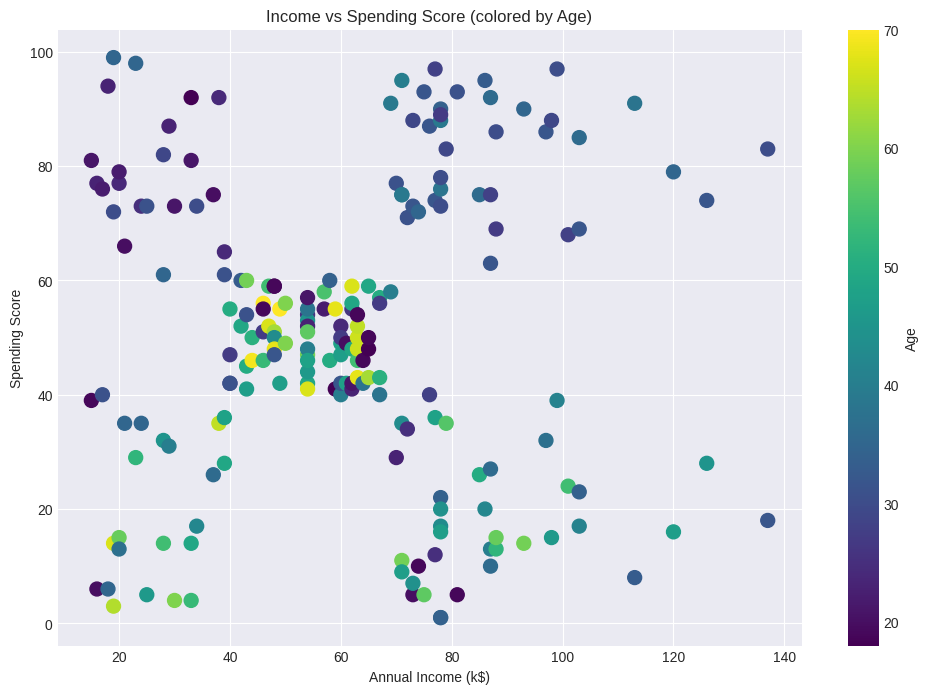

<Figure size 1200x800 with 0 Axes>

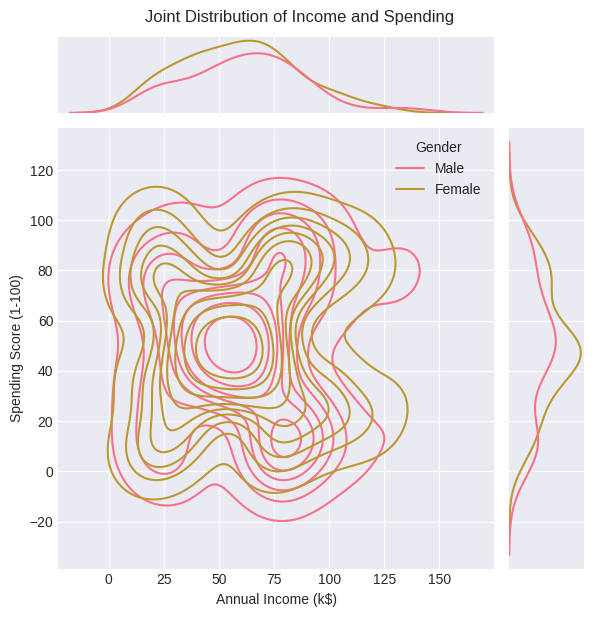

In [35]:
def create_advanced_visualizations(df):
    """
    Create advanced visualizations for deeper insights
    """
    # 1. Age and Spending Distribution by Gender
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    sns.kdeplot(data=df, x='Age', hue='Gender', multiple="layer")
    plt.title('Age Distribution by Gender')

    plt.subplot(1, 2, 2)
    sns.kdeplot(data=df, x='Spending Score (1-100)', hue='Gender', multiple="layer")
    plt.title('Spending Score Distribution by Gender')

    plt.tight_layout()

    # 2. Income vs Spending with Age
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(df['Annual Income (k$)'],
                         df['Spending Score (1-100)'],
                         c=df['Age'],
                         cmap='viridis',
                         s=100)
    plt.colorbar(scatter, label='Age')
    plt.xlabel('Annual Income (k$)')
    plt.ylabel('Spending Score')
    plt.title('Income vs Spending Score (colored by Age)')

    # 3. Feature Relationships
    plt.figure(figsize=(12, 8))
    sns.jointplot(data=df,
                  x='Annual Income (k$)',
                  y='Spending Score (1-100)',
                  hue='Gender',
                  kind='kde')
    plt.suptitle('Joint Distribution of Income and Spending', y=1.02)

# Create advanced visualizations
create_advanced_visualizations(enhanced_data)

# 5. Advanced Customer Segmentation

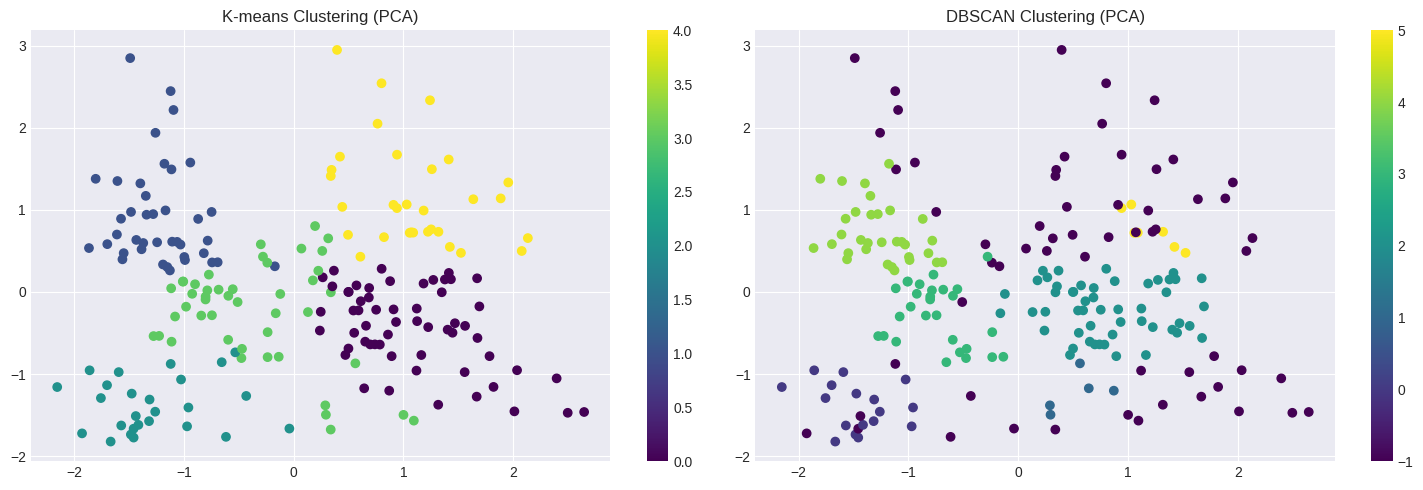

In [36]:
def perform_advanced_clustering(df):
    """
    Perform advanced clustering analysis using multiple techniques
    """
    # Prepare data for clustering
    features = ['Annual Income (k$)', 'Spending Score (1-100)', 'Age']
    X = df[features].values

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 1. K-means clustering
    kmeans = KMeans(n_clusters=5, random_state=42)
    kmeans_labels = kmeans.fit_predict(X_scaled)

    # 2. DBSCAN clustering
    dbscan = DBSCAN(eps=0.5, min_samples=5)
    dbscan_labels = dbscan.fit_predict(X_scaled)

    # 3. PCA for visualization
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    # Visualize results
    fig = plt.figure(figsize=(15, 5))

    # K-means results
    plt.subplot(1, 2, 1)
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis')
    plt.title('K-means Clustering (PCA)')
    plt.colorbar(scatter)

    # DBSCAN results
    plt.subplot(1, 2, 2)
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='viridis')
    plt.title('DBSCAN Clustering (PCA)')
    plt.colorbar(scatter)

    plt.tight_layout()

    return kmeans_labels, dbscan_labels

# Perform advanced clustering
kmeans_labels, dbscan_labels = perform_advanced_clustering(enhanced_data)

# 6. Segment Profiling

Segment Profiles:


Age         Annual Income (k$)          Spending Score (1-100)      \
          mean min max               mean min  max                   mean min   
Segment                                                                         
0        55.28  40  70              47.62  19   67                  41.71   3   
1        32.88  27  40              86.10  69  137                  81.53  58   
2        25.77  18  35              26.12  15   42                  74.85  39   
3        26.73  18  40              54.31  16   81                  40.91   5   
4        44.39  32  59              89.77  71  137                  18.48   1   

              Gender Spending_to_Income_Ratio  
        max <lambda>                     mean  
Segment                                        
0        60   Female                     0.86  
1        97   Female                     0.97  
2        99   Female                     3.16  
3        60   Female                     0.80  
4        39     Male                     0.21

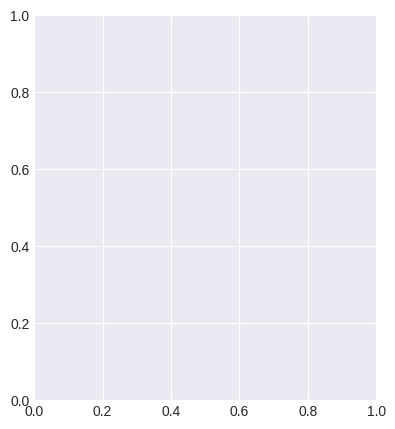

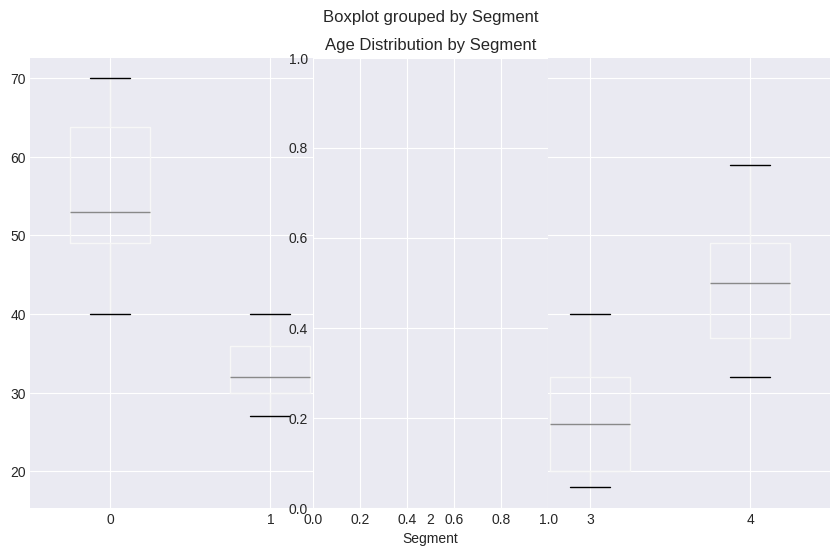

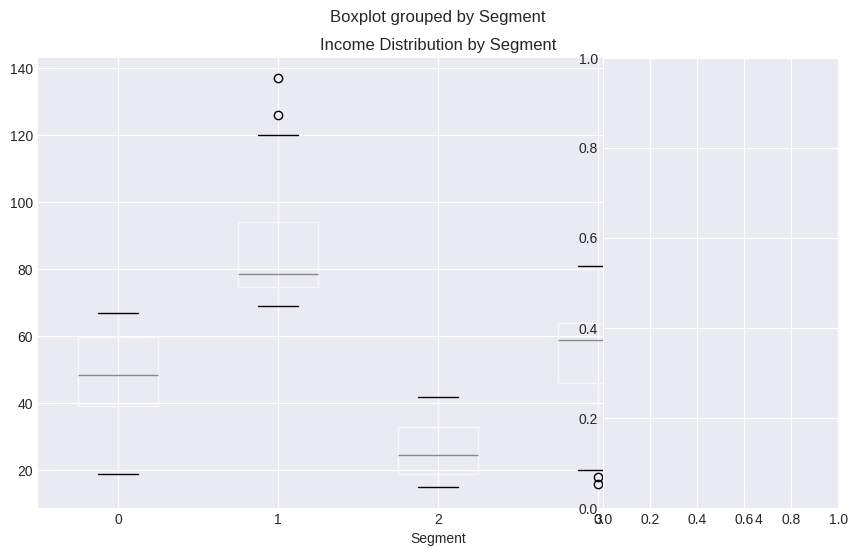

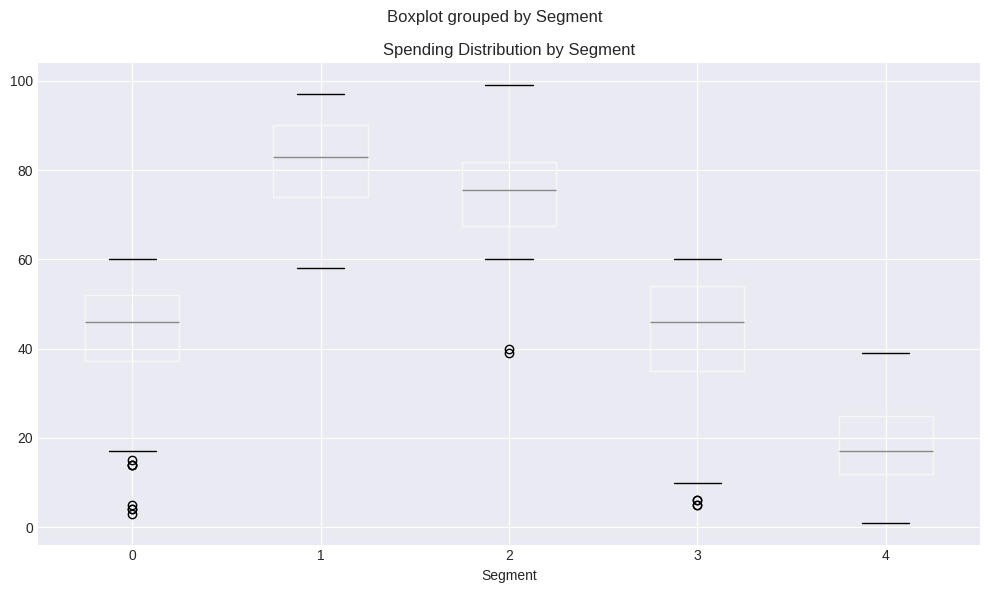

In [37]:
def profile_segments(df, labels):
    """
    Create detailed profiles for each customer segment
    """
    df_profile = df.copy()
    df_profile['Segment'] = labels

    # Calculate segment profiles
    profiles = df_profile.groupby('Segment').agg({
        'Age': ['mean', 'min', 'max'],
        'Annual Income (k$)': ['mean', 'min', 'max'],
        'Spending Score (1-100)': ['mean', 'min', 'max'],
        'Gender': lambda x: x.value_counts().index[0],
        'Spending_to_Income_Ratio': 'mean'
    }).round(2)

    # Calculate segment sizes
    segment_sizes = df_profile['Segment'].value_counts().sort_index()

    print("Segment Profiles:")
    display(profiles)

    # Visualize segment characteristics
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    df_profile.boxplot(column='Age', by='Segment')
    plt.title('Age Distribution by Segment')

    plt.subplot(1, 3, 2)
    df_profile.boxplot(column='Annual Income (k$)', by='Segment')
    plt.title('Income Distribution by Segment')

    plt.subplot(1, 3, 3)
    df_profile.boxplot(column='Spending Score (1-100)', by='Segment')
    plt.title('Spending Distribution by Segment')

    plt.tight_layout()

# Profile customer segments
enhanced_data['Segment'] = kmeans_labels
profile_segments(enhanced_data, kmeans_labels)